<a href="https://colab.research.google.com/github/pranav-ANIL/DL-and-ML-projects/blob/main/Heart%20attack%20prediction/HRT_ATTK_pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/Patients Data ( Used for Heart Disease Prediction ) (6).csv", encoding='latin1')
df

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
ÿPatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(0)

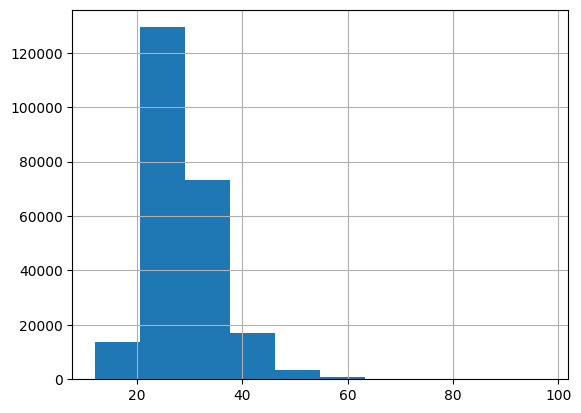

In [ ]:
df["BMI"].hist()
plt.show()

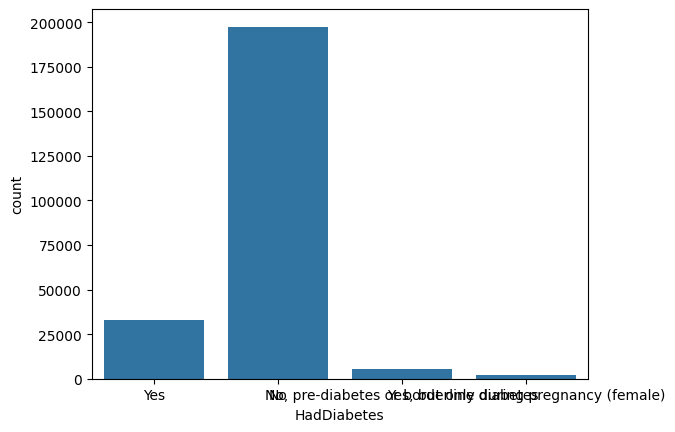

In [ ]:
sns.countplot(x=df["HadDiabetes"])
plt.show()

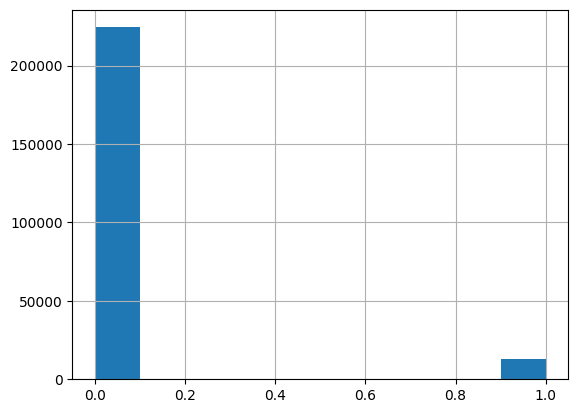

In [ ]:
df["HadHeartAttack"].hist()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df["State"].unique() #nc

array(['Alabama', 'Alaska', 'Arizona', 'California', 'Arkansas',
       'Connecticut', 'Colorado', 'Delaware', 'Florida', 'Georgia',
       'Hawaii', 'Idaho', 'Indiana', 'District of Columbia', 'Kansas',
       'Iowa', 'Maryland', 'Minnesota', 'Montana', 'New Jersey',
       'Nebraska', 'New York', 'Ohio', 'Oklahoma', 'Texas', 'Vermont',
       'Washington', 'Utah', 'Illinois', 'West Virginia', 'Virginia',
       'Massachusetts', 'Kentucky', 'Louisiana', 'Maine', 'Wisconsin',
       'Michigan', 'Mississippi', 'Missouri', 'Nevada', 'New Hampshire',
       'New Mexico', 'South Carolina', 'North Carolina', 'North Dakota',
       'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota',
       'Tennessee', 'Wyoming', 'Guam', 'Puerto Rico', 'Virgin Islands'],
      dtype=object)

In [ ]:
df["Sex"].unique() #nc

array(['Female', 'Male'], dtype=object)

In [ ]:
df["GeneralHealth"].unique()#oc

array(['Fair', 'Very good', 'Excellent', 'Good', 'Poor'], dtype=object)

In [ ]:
df["AgeCategory"].unique()#oc

array(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
       'Age 50 to 54', 'Age 80 or older', 'Age 55 to 59', 'Age 25 to 29',
       'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24',
       'Age 45 to 49'], dtype=object)

In [ ]:
df["HadDiabetes"].unique() #nc

array(['Yes', 'No', 'No, pre-diabetes or borderline diabetes',
       'Yes, but only during pregnancy (female)'], dtype=object)

In [ ]:
df["SmokerStatus"].unique() #nc

array(['Former smoker', 'Never smoked',
       'Current smoker - now smokes every day',
       'Current smoker - now smokes some days'], dtype=object)

In [ ]:
df["ECigaretteUsage"].unique()#oc

array(['Never used e-cigarettes in my entire life',
       'Not at all (right now)', 'Use them some days',
       'Use them every day'], dtype=object)

In [ ]:
df["RaceEthnicityCategory"].unique()#nc

array(['White only, Non-Hispanic', 'Black only, Non-Hispanic',
       'Other race only, Non-Hispanic', 'Multiracial, Non-Hispanic',
       'Hispanic'], dtype=object)

In [ ]:
df["TetanusLast10Tdap"].unique()#nc

array(['No, did not receive any tetanus shot in the past 10 years',
       'Yes, received Tdap',
       'Yes, received tetanus shot but not sure what type',
       'Yes, received tetanus shot, but not Tdap'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["TetanusLast10Tdap"]=le.fit_transform(df["TetanusLast10Tdap"])
df["State"]=le.fit_transform(df["TetanusLast10Tdap"])
df["RaceEthnicityCategory"]=le.fit_transform(df["RaceEthnicityCategory"])
df["SmokerStatus"]=le.fit_transform(df["SmokerStatus"])
df["HadDiabetes"]=le.fit_transform(df["HadDiabetes"])
df["Sex"]=le.fit_transform(df["Sex"])

In [ ]:
df["ECigaretteUsage"].replace(['Never used e-cigarettes in my entire life',
       'Not at all (right now)', 'Use them some days',
       'Use them every day'],[0,1,2,3],inplace=True)

/tmp/ipykernel_5027/3416297420.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ECigaretteUsage"].replace(['Never used e-cigarettes in my entire life',
/tmp/ipykernel_5027/3416297420.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["ECigaretteUsage"].replace(['Never used e-cigarettes in

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df["AgeCategory"].replace(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
       'Age 50 to 54', 'Age 80 or older', 'Age 55 to 59', 'Age 25 to 29',
       'Age 40 to 44', 'Age 30 to 34', 'Age 35 to 39', 'Age 18 to 24',
       'Age 45 to 49'],[0,1,2,3,4,5,6,7,8,9,10,11,12],inplace=True)

/tmp/ipykernel_5027/4200873685.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["AgeCategory"].replace(['Age 75 to 79', 'Age 65 to 69', 'Age 60 to 64', 'Age 70 to 74',
/tmp/ipykernel_5027/4200873685.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["AgeCategory"].replace(['Age 75 to 79', 

In [ ]:
df["GeneralHealth"].replace(['Fair', 'Very good', 'Excellent', 'Good', 'Poor'],[0,1,2,3,4],inplace=True)

/tmp/ipykernel_5027/2968002489.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GeneralHealth"].replace(['Fair', 'Very good', 'Excellent', 'Good', 'Poor'],[0,1,2,3,4],inplace=True)
/tmp/ipykernel_5027/2968002489.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["GeneralHealth"].replace([

In [ ]:

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# features and target
X = df[[
    "Sex", "GeneralHealth", "HeightInMeters", "HadAngina",
    "HadSkinCancer", "HadCOPD", "HadKidneyDisease",
    "HadArthritis", "HadDiabetes", "DeafOrHardOfHearing",
    "DifficultyWalking", "DifficultyDressingBathing",
    "DifficultyErrands", "SmokerStatus", "ChestScan",
    "AlcoholDrinkers", "PneumoVaxEver"
]]

y = df["HadHeartAttack"]

# encode categorical columns
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# encode target
y = LabelEncoder().fit_transform(y)

# apply SMOTE
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)

# combine into single dataframe
df_smote = pd.concat(
    [
        pd.DataFrame(X_smote, columns=X.columns),
        pd.DataFrame(y_smote, columns=["HadHeartAttack"])
    ],
    axis=1
)

# check results
print(df["HadHeartAttack"].value_counts())
print(df_smote["HadHeartAttack"].value_counts())

print(df_smote.head())


HadHeartAttack
0    224429
1     13201
Name: count, dtype: int64
HadHeartAttack
0    224429
1    224429
Name: count, dtype: int64
   Sex  GeneralHealth  HeightInMeters  HadAngina  HadSkinCancer  HadCOPD  \
0    0              0            1.63          1              1        0   
1    0              1            1.60          0              0        0   
2    1              2            1.78          0              0        0   
3    1              1            1.78          0              0        0   
4    0              3            1.68          0              0        0   

   HadKidneyDisease  HadArthritis  HadDiabetes  DeafOrHardOfHearing  \
0                 0             1            2                    0   
1                 0             1            0                    0   
2                 0             0            0                    0   
3                 0             1            2                    0   
4                 0             0            0            

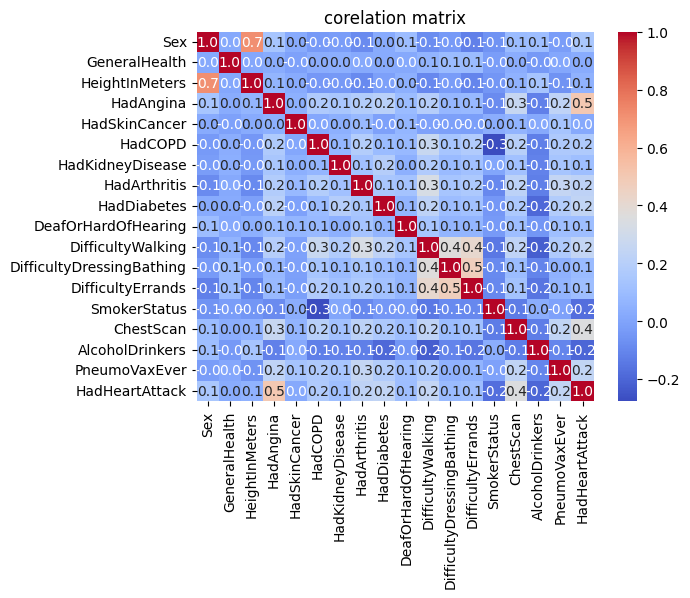

In [ ]:
corr_matrix=df_smote.corr()
sns.heatmap(corr_matrix,annot=True,fmt="0.01f",cmap="coolwarm")
plt.title("corelation matrix")
plt.show()

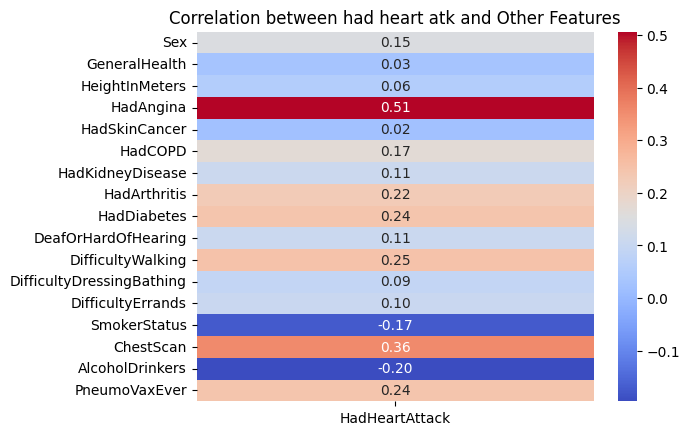

In [ ]:

tk_corr = df_smote.corr()['HadHeartAttack']
tk_corr = tk_corr.drop('HadHeartAttack')
sns.heatmap(tk_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between had heart atk and Other Features')
plt.show()

In [ ]:
df_smote

,Sex,GeneralHealth,HeightInMeters,HadAngina,HadSkinCancer,HadCOPD,HadKidneyDisease,HadArthritis,HadDiabetes,DeafOrHardOfHearing,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ChestScan,AlcoholDrinkers,PneumoVaxEver,HadHeartAttack
0,0,0,1.630000,1,1,0,0,1,2,0,1,0,0,2,1,0,1,0
1,0,1,1.600000,0,0,0,0,1,0,0,0,0,0,2,0,0,1,0
2,1,2,1.780000,0,0,0,0,0,0,0,0,0,0,3,0,1,0,0
3,1,1,1.780000,0,0,0,0,1,2,0,0,0,0,2,0,0,1,0
4,0,3,1.680000,0,0,0,0,0,0,0,0,0,0,3,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448853,0,4,1.625955,1,0,1,0,1,0,0,1,1,1,0,1,0,0,1
448854,0,3,1.479530,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
448855,1,2,1.785364,0,1,0,0,0,0,0,0,0,0,1,1,1,0,1
448856,0,0,1.649300,1,0,0,0,1,0,1,0,0,0,3,1,0,1,1


<Axes: >

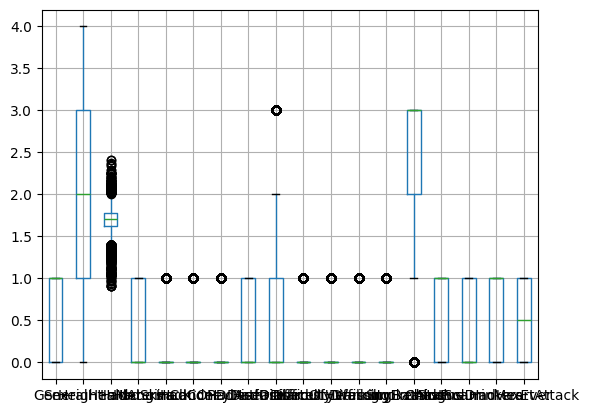

In [ ]:
df_smote.boxplot()

In [ ]:
def remove_outliers_iqr(df_smote, exclude_column):
    for col in df_smote.columns:
        if col == exclude_column:
            continue
        Q1 = df_smote[col].quantile(0.25)
        Q3 = df_smote[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_smote = df_smote[(df_smote[col] >= lower_bound) & (df_smote[col] <= upper_bound)]
    return df_smote


df_cleaned = remove_outliers_iqr(df_smote, exclude_column='survived')
df_smote=df_cleaned

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features = [	"Sex"	,"GeneralHealth"	,"HeightInMeters","HadAngina",	"HadSkinCancer",	"HadCOPD",	"HadKidneyDisease",	"HadArthritis",	"HadDiabetes",
            "DeafOrHardOfHearing"	,"DifficultyWalking",	"DifficultyDressingBathing",	'DifficultyErrands',"SmokerStatus",	"ChestScan",	"AlcoholDrinkers",	"PneumoVaxEver"]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_smote[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

# CROSS VALIDATION

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
x=df_smote[["Sex"	,"GeneralHealth"	,"HeightInMeters","HadAngina",	"HadSkinCancer",	"HadCOPD",	"HadKidneyDisease",	"HadArthritis",	"HadDiabetes",
            "DeafOrHardOfHearing"	,"DifficultyWalking",	"DifficultyDressingBathing",	'DifficultyErrands',"SmokerStatus",	"ChestScan",	"AlcoholDrinkers",	"PneumoVaxEver"]]
y = df_smote["HadHeartAttack"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'logisic regression accuracy: {accuracy:.2f}')

logisic regression accuracy: 0.81


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
x=df_smote[["Sex"	,"GeneralHealth"	,"HeightInMeters","HadAngina",	"HadSkinCancer",	"HadCOPD",	"HadKidneyDisease",	"HadArthritis",	"HadDiabetes",
            "DeafOrHardOfHearing"	,"DifficultyWalking",	"DifficultyDressingBathing",	'DifficultyErrands',"SmokerStatus",	"ChestScan",	"AlcoholDrinkers",	"PneumoVaxEver"]]
y=df_smote["HadHeartAttack"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model1=RandomForestClassifier()
model1.fit(x_train,y_train)
y1_pred=model1.predict(x_test)
accuracy=accuracy_score(y_test,y1_pred)
print(f"Randomforestclassifier accuracy:{accuracy:0.2f}")

Randomforestclassifier accuracy:0.92


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
x=df_smote[["Sex"	,"GeneralHealth"	,"HeightInMeters","HadAngina",	"HadSkinCancer",	"HadCOPD",	"HadKidneyDisease",	"HadArthritis",	"HadDiabetes",
            "DeafOrHardOfHearing"	,"DifficultyWalking",	"DifficultyDressingBathing",	'DifficultyErrands',"SmokerStatus",	"ChestScan",	"AlcoholDrinkers",	"PneumoVaxEver"]]
y=df_smote["HadHeartAttack"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LinearSVC())
])
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"svc accuracy:{accuracy:0.2f}")

svc accuracy:0.80


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
x = df[["Sex"	,"GeneralHealth"	,"HeightInMeters","HadAngina",	"HadSkinCancer",	"HadCOPD",	"HadKidneyDisease",	"HadArthritis",	"HadDiabetes",
            "DeafOrHardOfHearing"	,"DifficultyWalking",	"DifficultyDressingBathing",	'DifficultyErrands',"SmokerStatus",	"ChestScan",	"AlcoholDrinkers",	"PneumoVaxEver"]]
y = df["HadHeartAttack"]
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.69, random_state=1)
model = DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"baseline model accuracy:{accuracy:0.2f}")

baseline model accuracy:0.93


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
x=df_smote[["Sex"	,"GeneralHealth"	,"HeightInMeters","HadAngina",	"HadSkinCancer",	"HadCOPD",	"HadKidneyDisease",	"HadArthritis",	"HadDiabetes",
            "DeafOrHardOfHearing"	,"DifficultyWalking",	"DifficultyDressingBathing",	'DifficultyErrands',"SmokerStatus",	"ChestScan",	"AlcoholDrinkers",	"PneumoVaxEver"]]
y=df_smote["HadHeartAttack"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model1=XGBClassifier()
model1.fit(x_train,y_train)
y1_pred=model1.predict(x_test)
accuracy=accuracy_score(y_test,y1_pred)
print(f"xgb accuracy:{accuracy:0.2f}")

xgb accuracy:0.91


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
x=df_smote[["Sex"	,"GeneralHealth"	,"HeightInMeters","HadAngina",	"HadSkinCancer",	"HadCOPD",	"HadKidneyDisease",	"HadArthritis",	"HadDiabetes",
            "DeafOrHardOfHearing"	,"DifficultyWalking",	"DifficultyDressingBathing",	'DifficultyErrands',"SmokerStatus",	"ChestScan",	"AlcoholDrinkers",	"PneumoVaxEver"]]
y=df_smote["HadHeartAttack"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model1=AdaBoostClassifier()
model1.fit(x_train,y_train)
y1_pred=model1.predict(x_test)
accuracy=accuracy_score(y_test,y1_pred)
print(f"AdaBoostClassifier:{accuracy:0.2f}")

AdaBoostClassifier:0.82


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# KFOLD

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
x = df_smote.drop("HadHeartAttack",axis=1)
y = df_smote["HadHeartAttack"]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()
best_accuracy = 0
best_fold = -1
best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")
    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_x_train = x_train
        best_y_train = y_train
        best_x_test = x_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.8084248985842087
Fold 2 Accuracy: 0.8071570576540755
Fold 3 Accuracy: 0.809010800064478
Fold 4 Accuracy: 0.808419751759712
Fold 5 Accuracy: 0.8082316909354683

 Best Fold: 3 with Accuracy: 0.809010800064478


In [ ]:
model = LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.809010800064478

In [ ]:
model = RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9217666971146097

In [ ]:
model = LinearSVC()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8095749825372092

In [ ]:
model = DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9301219708774381

In [ ]:
model = XGBClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9092740852184192

In [ ]:
model = AdaBoostClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.8212616194723551

# DL

In [ ]:
model = Sequential()
model.add(Dense(128, input_dim=17, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [ ]:
model.fit(x_train,y_train,epochs=20,batch_size=42)

Epoch 1/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8106 - loss: 0.4221
Epoch 2/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8140 - loss: 0.4145
Epoch 3/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8142 - loss: 0.4124
Epoch 4/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8152 - loss: 0.4106
Epoch 5/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8154 - loss: 0.4095
Epoch 6/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8168 - loss: 0.4080
Epoch 7/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8173 - loss: 0.4069
Epoch 8/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8177 - loss: 0.4060
Epoch 9/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8182 - loss: 0.4050
Epoch 10/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8181 - loss: 0.4046
Epoch 11/20
3324/3324 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8183 - loss: 0.4038
Epoch 12/20
3324/3324 ━━━━━━━

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"model accuracy:{accuracy}")

1454/1454 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8209 - loss: 0.4024
model accuracy:0.8208605647087097


## **CONCLUSIION**


This project focused on predicting the likelihood of heart attack occurrence using machine learning techniques. One of the major challenges in the dataset was class imbalance, where the number of samples in one class was significantly higher than the other. To address this issue, the SMOTE (Synthetic Minority Over-sampling Technique) method was applied, which helped create a balanced dataset and improved the model’s ability to correctly identify minority class instances.

Several machine learning models were trained and evaluated using both Train-Test Split validation and K-Fold Cross Validation techniques to ensure reliable and unbiased performance measurement. Cross-validation helped verify the consistency and generalization capability of the models across different subsets of the dataset.

Among all the evaluated models, the Decision Tree Classifier achieved the highest accuracy in both the Train-Test Split evaluation and K-Fold Cross Validation. This indicates that the Decision Tree model was able to effectively capture the patterns and relationships present in the heart attack dataset.

Overall, the project demonstrates that proper data preprocessing, handling class imbalance using SMOTE, and applying robust validation techniques can significantly improve the performance of predictive healthcare models. The developed model can assist in early heart attack risk prediction and support medical decision-making processes.
